# Batch Analysis — Lid-Driven Cavity at Re = 100, 400, 1000

Runs the fractional-step solver for three Reynolds numbers and produces
combined 3-row comparison plots.
Results are saved to `results/Re{Re}.npz` so the plotting cells can be
re-run independently without re-solving.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.sparse.linalg import cg, LinearOperator

import operators as ops

## Shared Grid Parameters (Re-independent)

In [2]:
RE_LIST = [100, 400, 1000]

nx, ny  = 65, 65
Lx, Ly  = 1.0, 1.0
Ustar   = 1.0
CFL     = 0.1
xL, xR  = 0.0, Lx
yB, yT  = 0.0, Ly

n_cells = nx * ny
n_vel   = ny * (nx - 1) + nx * (ny - 1)
dx      = Lx / nx
dy      = Ly / ny
dt      = CFL * dx
max_step = 25000
end_time = max_step * dt

print(f'dt={dt:.5f}  n_cells={n_cells}  n_vel={n_vel}  max_step={max_step}  end_time={end_time:.4f}')

dt=0.00154  n_cells=4225  n_vel=8320  max_step=25000  end_time=38.4615


## Grid Indexing and Coordinates

In [3]:
def func_gen_pointer(nx, ny):
    ip = np.full((nx, ny), -1, dtype=int)
    count = 0
    for i in range(nx):
        for j in range(ny):
            ip[i, j] = count
            count += 1

    iu = np.full((nx + 1, ny), -1, dtype=int)
    count = 0
    for i in range(1, nx):
        for j in range(ny):
            iu[i, j] = count
            count += 1

    iv = np.full((nx, ny + 1), -1, dtype=int)
    count = ny * (nx - 1)
    for i in range(nx):
        for j in range(1, ny):
            iv[i, j] = count
            count += 1

    return ip, iu, iv


ip, iu, iv = func_gen_pointer(nx, ny)

xp = np.linspace(xL + dx / 2, xR - dx / 2, nx)
yp = np.linspace(yB + dy / 2, yT - dy / 2, ny)
xu = np.linspace(xL + dx, xR - dx, nx - 1)
yu = yp.copy()
xv = xp.copy()
yv = np.linspace(yB + dy, yT - dy, ny - 1)

## Boundary Conditions (Re-independent)

In [4]:
uBC_T = Ustar * np.ones(nx - 1)
uBC_B = np.zeros(nx - 1)
uBC_L = np.zeros(ny)
uBC_R = np.zeros(ny)

vBC_T = np.zeros(nx)
vBC_B = np.zeros(nx)
vBC_L = np.zeros(ny - 1)
vBC_R = np.zeros(ny - 1)

## Solver

Three-step fractional-step (projection) method:
1. Intermediate velocity via Crank-Nicolson + Adams-Bashforth
2. Pressure Poisson solve
3. Velocity correction to enforce divergence-free condition

In [5]:
def run_solver(Re):
    visc = Ustar * Lx / Re

    P        = np.zeros(n_cells)
    U        = np.zeros(n_vel)
    time     = 0.0
    step     = 0
    adv_prev = np.zeros(n_vel)

    def laplace_x(x):
        return ops.L(x, dx, iu, iv, nx, ny, n_vel)

    def opt_S(x): return x + (dt / 2.0 * visc) * laplace_x(x)
    def opt_R(x): return x - (dt / 2.0 * visc) * laplace_x(x)
    def opt_G(x): return ops.G(x, dx, ip, iu, iv, nx, ny, n_vel)
    def opt_D(x): return ops.D(x, dx, ip, iu, iv, nx, ny, n_cells)

    def opt_T(x):
        y = opt_D(opt_S(opt_G(x)))
        y[ip[0, 0]] = 0.0
        return y

    def opt_C(x): return opt_S(opt_G(x))

    def adv(vel):
        return ops.A(vel, uBC_L, uBC_R, uBC_B, uBC_T,
                     vBC_L, vBC_R, vBC_B, vBC_T,
                     dx, iu, iv, nx, ny, n_vel)

    bc_L_val = ops.bc_L(uBC_L, uBC_R, uBC_B, uBC_T,
                        vBC_L, vBC_R, vBC_B, vBC_T,
                        dx, iu, iv, nx, ny, n_vel)
    bc_D_val = ops.bc_D(uBC_L, uBC_R, vBC_B, vBC_T,
                        dx, ip, nx, ny, n_cells)

    def cg_solve(op, b, tol=1e-8):
        A_op = LinearOperator((len(b), len(b)), matvec=op, dtype=np.float64)
        x, info = cg(A_op, b, rtol=tol)
        if info != 0:
            print(f'  CG warning: info={info}')
        return x

    print(f'Re = {Re}: running (max_step={max_step}, end_time={end_time:.4f})')
    while time < end_time:
        step += 1
        time += dt

        adv0 = adv(U)
        adv1 = adv_prev

        # Step 1: intermediate velocity
        RHS_U = opt_S(U) + dt * (1.5 * adv0 - 0.5 * adv1) + dt * visc * bc_L_val
        UF    = cg_solve(opt_R, RHS_U)

        # Step 2: pressure Poisson
        RHS_P = opt_D(UF) / dt + bc_D_val / dt
        RHS_P[ip[0, 0]] = 0.0
        P = cg_solve(opt_T, RHS_P)

        # Step 3: velocity correction
        U = UF - dt * opt_C(P)

        adv_prev = adv0

        if step % 100 == 0:
            res = np.linalg.norm(U - UF) / (np.linalg.norm(U) + 1e-15)
            print(f'  step={step:5d}  t={time:.4f}  ||U||={np.linalg.norm(U):.4e}  res={res:.2e}')

    np.savez(f'results/Re{int(Re)}.npz', P=P, U=U, time=time, step=step, Re=Re)
    print(f'Re = {Re}: saved to results/Re{int(Re)}.npz')

## Run All Reynolds Numbers

Skips any Re for which `results/Re{Re}.npz` already exists.
**This is the only expensive cell** — re-running the notebook after completion is fast.

In [6]:
os.makedirs('results', exist_ok=True)
for Re in RE_LIST:
    path = f'results/Re{int(Re)}.npz'
    if os.path.exists(path):
        print(f'Re = {Re}: results found at {path}, skipping solver.')
    else:
        run_solver(Re)

Re = 100: running (max_step=25000, end_time=38.4615)
  step=  100  t=0.1538  ||U||=9.6145e+00  res=1.69e-02
  step=  200  t=0.3077  ||U||=1.1202e+01  res=1.47e-02
  step=  300  t=0.4615  ||U||=1.2157e+01  res=1.36e-02
  step=  400  t=0.6154  ||U||=1.2834e+01  res=1.29e-02
  step=  500  t=0.7692  ||U||=1.3351e+01  res=1.25e-02
  step=  600  t=0.9231  ||U||=1.3764e+01  res=1.21e-02
  step=  700  t=1.0769  ||U||=1.4104e+01  res=1.19e-02
  step=  800  t=1.2308  ||U||=1.4389e+01  res=1.17e-02
  step=  900  t=1.3846  ||U||=1.4634e+01  res=1.15e-02
  step= 1000  t=1.5385  ||U||=1.4846e+01  res=1.13e-02
  step= 1100  t=1.6923  ||U||=1.5033e+01  res=1.12e-02
  step= 1200  t=1.8462  ||U||=1.5198e+01  res=1.11e-02
  step= 1300  t=2.0000  ||U||=1.5345e+01  res=1.10e-02
  step= 1400  t=2.1538  ||U||=1.5477e+01  res=1.09e-02
  step= 1500  t=2.3077  ||U||=1.5597e+01  res=1.08e-02
  step= 1600  t=2.4615  ||U||=1.5705e+01  res=1.08e-02
  step= 1700  t=2.6154  ||U||=1.5804e+01  res=1.07e-02
  step= 1800

## Load Results

In [7]:
data = {}
for Re in RE_LIST:
    d = np.load(f'results/Re{int(Re)}.npz')
    data[Re] = {'P': d['P'], 'U': d['U']}
    print(f'Re = {Re}: loaded (t={float(d["time"]):.4f}, step={int(d["step"])})')

Re = 100: loaded (t=38.4631, step=25001)
Re = 400: loaded (t=38.4631, step=25001)
Re = 1000: loaded (t=38.4631, step=25001)


## Ghia et al. (1982) Reference Data

In [8]:
ghia_data = {
    100: {
        'y_for_u': [1.0000, 0.9766, 0.9688, 0.9609, 0.9531,
                    0.8516, 0.7344, 0.6172, 0.5000, 0.4531,
                    0.2813, 0.1719, 0.1016, 0.0703, 0.0625,
                    0.0547, 0.0000],
        'u':       [ 1.00000,  0.84123,  0.78871,  0.73722,  0.68717,
                     0.23151,  0.00332, -0.13641, -0.20581, -0.21090,
                    -0.15662, -0.10150, -0.06434, -0.04775, -0.04192,
                    -0.03717,  0.00000],
        'x_for_v': [1.0000, 0.9688, 0.9609, 0.9531, 0.9453,
                    0.9063, 0.8594, 0.8047, 0.5000, 0.2344,
                    0.2266, 0.1563, 0.0938, 0.0781, 0.0703,
                    0.0625, 0.0000],
        'v':       [ 0.00000, -0.05906, -0.07391, -0.08864, -0.10313,
                    -0.16914, -0.22445, -0.24533,  0.05454,  0.17527,
                     0.17507,  0.16077,  0.12317,  0.10890,  0.10091,
                     0.09233,  0.00000],
    },
    400: {
        'y_for_u': [1.0000, 0.9766, 0.9688, 0.9609, 0.9531,
                    0.8516, 0.7344, 0.6172, 0.5000, 0.4531,
                    0.2813, 0.1719, 0.1016, 0.0703, 0.0625,
                    0.0547, 0.0000],
        'u':       [ 1.00000,  0.75837,  0.68439,  0.61756,  0.55892,
                     0.29093,  0.16256,  0.02135, -0.11477, -0.17119,
                    -0.32726, -0.24299, -0.14612, -0.10338, -0.09266,
                    -0.08186,  0.00000],
        'x_for_v': [1.0000, 0.9688, 0.9609, 0.9531, 0.9453,
                    0.9063, 0.8594, 0.8047, 0.5000, 0.2344,
                    0.2266, 0.1563, 0.0938, 0.0781, 0.0703,
                    0.0625, 0.0000],
        'v':       [ 0.00000, -0.12146, -0.15663, -0.19254, -0.22847,
                    -0.23827, -0.44993, -0.38598,  0.05186,  0.30174,
                     0.30203,  0.28124,  0.22965,  0.20920,  0.19713,
                     0.18360,  0.00000],
    },
    1000: {
        'y_for_u': [1.0000, 0.9766, 0.9688, 0.9609, 0.9531,
                    0.8516, 0.7344, 0.6172, 0.5000, 0.4531,
                    0.2813, 0.1719, 0.1016, 0.0703, 0.0625,
                    0.0547, 0.0000],
        'u':       [ 1.00000,  0.65928,  0.57492,  0.51117,  0.46604,
                     0.33304,  0.18719,  0.05702, -0.06080, -0.10648,
                    -0.27805, -0.38289, -0.29730, -0.22220, -0.20196,
                    -0.18109,  0.00000],
        'x_for_v': [1.0000, 0.9688, 0.9609, 0.9531, 0.9453,
                    0.9063, 0.8594, 0.8047, 0.5000, 0.2344,
                    0.2266, 0.1563, 0.0938, 0.0781, 0.0703,
                    0.0625, 0.0000],
        'v':       [ 0.00000, -0.21388, -0.27669, -0.33714, -0.39188,
                    -0.51550, -0.42665, -0.31966,  0.02526,  0.32235,
                     0.33075,  0.37095,  0.32627,  0.30353,  0.29012,
                     0.27485,  0.00000],
    },
}

## Figure 1 — Velocity and Pressure Contours

3 rows × 3 columns: each row is one Reynolds number.
Saved to `results/contours.png`.

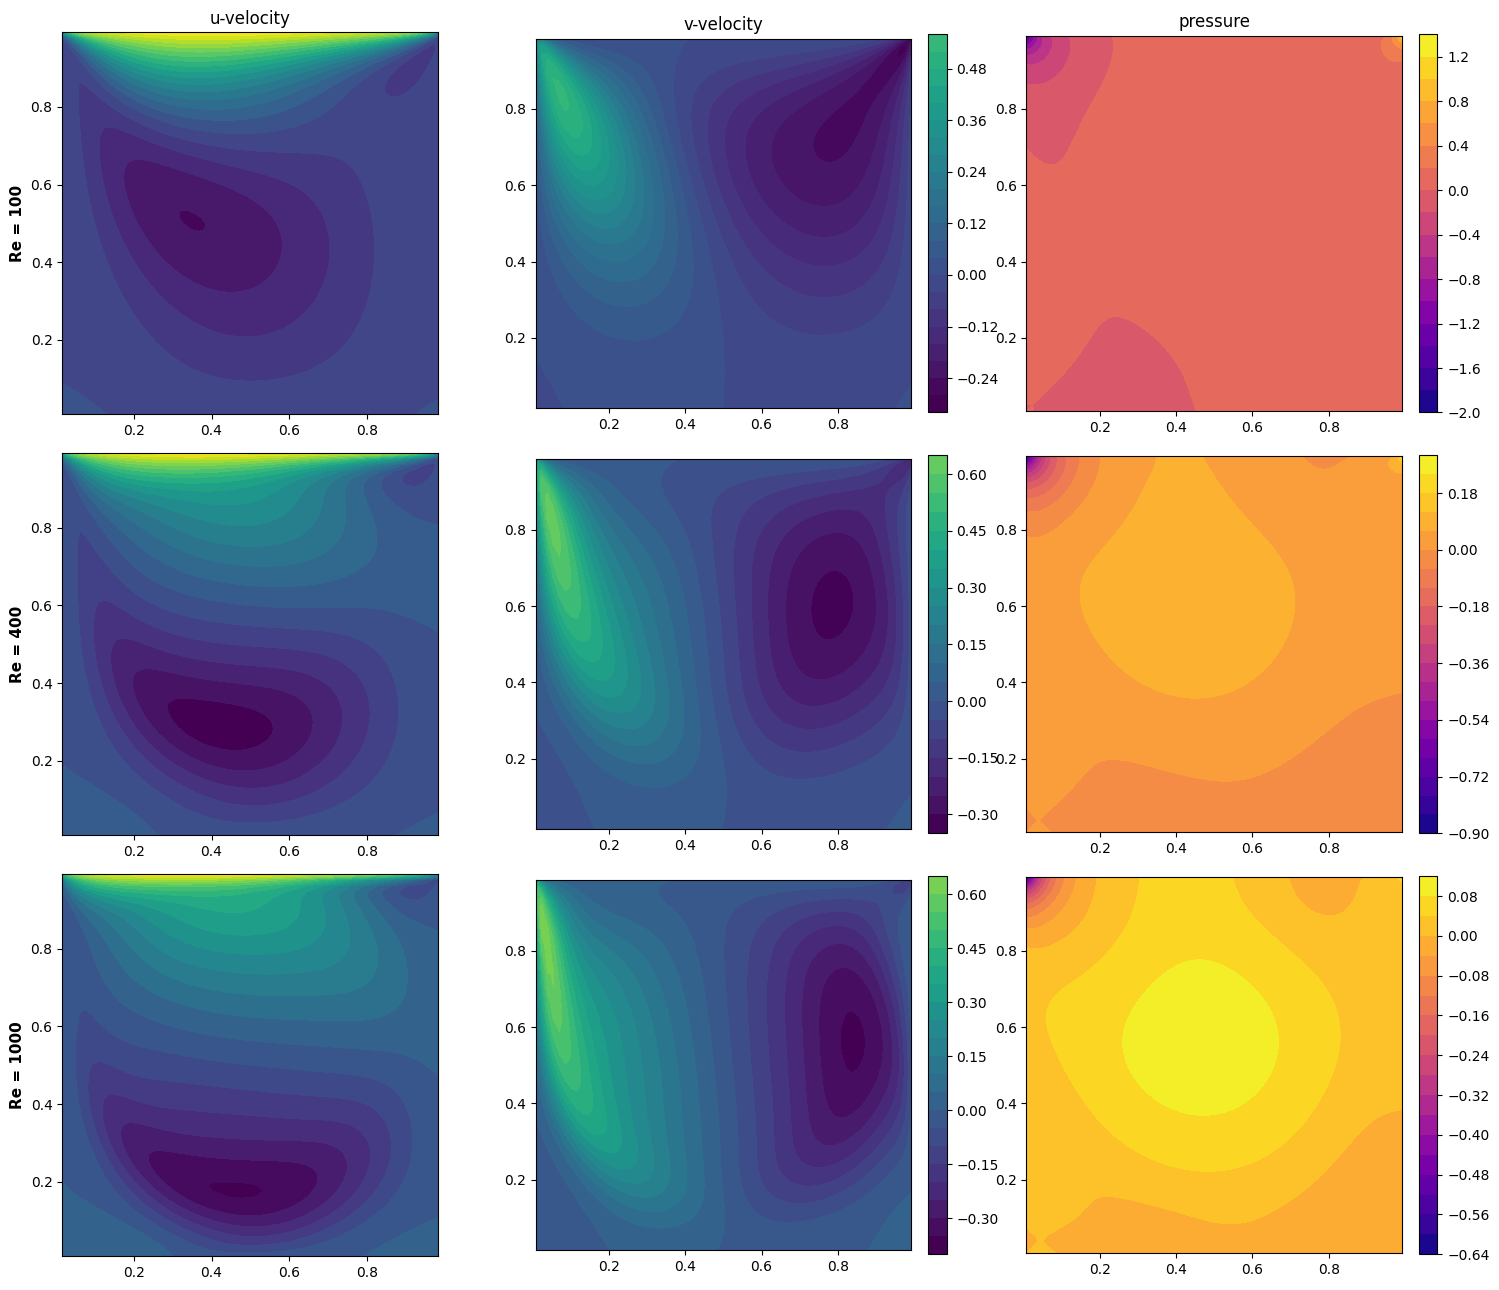

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13))

for row, Re in enumerate(RE_LIST):
    U_vec = data[Re]['U']
    P_vec = data[Re]['P']

    u_2d = U_vec[iu[1:nx, :ny]]   # (nx-1, ny)
    v_2d = U_vec[iv[:nx, 1:ny]]   # (nx, ny-1)
    p_2d = P_vec[ip]              # (nx, ny)

    vmin_vel = min(u_2d.min(), v_2d.min())
    vmax_vel = max(u_2d.max(), v_2d.max())

    cf_u = axes[row, 0].contourf(xu, yu, u_2d.T, levels=20,
                                  vmin=vmin_vel, vmax=vmax_vel, cmap='viridis')
    axes[row, 0].set_aspect('equal')
    axes[row, 0].set_ylabel(f'Re = {Re}', fontsize=11, fontweight='bold')
    if row == 0:
        axes[row, 0].set_title('u-velocity')

    cf_v = axes[row, 1].contourf(xv, yv, v_2d.T, levels=20,
                                  vmin=vmin_vel, vmax=vmax_vel, cmap='viridis')
    axes[row, 1].set_aspect('equal')
    fig.colorbar(cf_v, ax=axes[row, 1], fraction=0.046, pad=0.04)
    if row == 0:
        axes[row, 1].set_title('v-velocity')

    cf_p = axes[row, 2].contourf(xp, yp, p_2d.T, levels=20, cmap='plasma')
    axes[row, 2].set_aspect('equal')
    fig.colorbar(cf_p, ax=axes[row, 2], fraction=0.046, pad=0.04)
    if row == 0:
        axes[row, 2].set_title('pressure')

plt.tight_layout()
plt.savefig('results/contours.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 2 — Centreline Profiles and Streamlines

3 rows × 3 columns: each row is one Reynolds number.
Saved to `results/profiles_streamlines.png`.

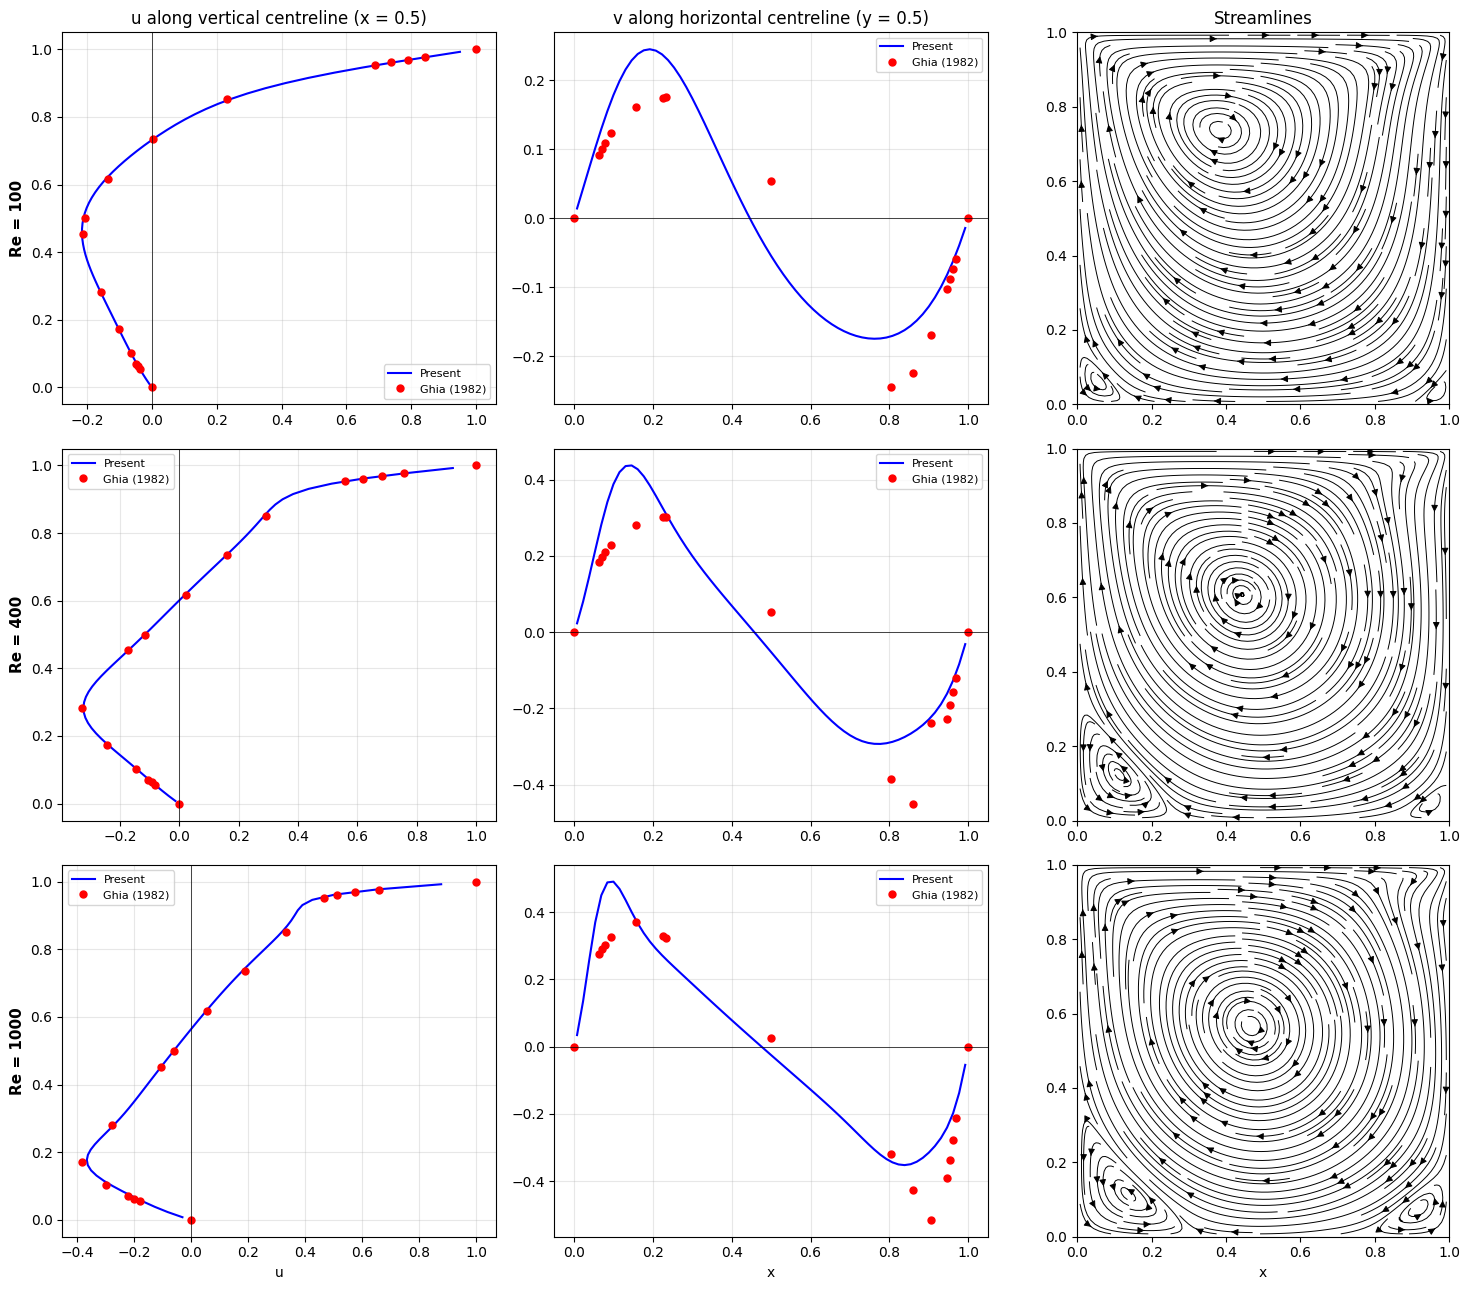

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13))

ix = np.argmin(np.abs(xu - 0.5))   # u-face index nearest x = 0.5
jy = np.argmin(np.abs(yv - 0.5))   # v-face index nearest y = 0.5

for row, Re in enumerate(RE_LIST):
    U_vec = data[Re]['U']
    ghia  = ghia_data[Re]

    u_2d = U_vec[iu[1:nx, :ny]]   # (nx-1, ny)
    v_2d = U_vec[iv[:nx, 1:ny]]   # (nx, ny-1)

    # cell-center velocities for streamplot (average staggered faces)
    u_ext = np.zeros((nx + 1, ny))
    u_ext[1:nx, :] = u_2d
    u_cc = 0.5 * (u_ext[:nx, :] + u_ext[1:, :])

    v_ext = np.zeros((nx, ny + 1))
    v_ext[:, 1:ny] = v_2d
    v_cc = 0.5 * (v_ext[:, :ny] + v_ext[:, 1:])

    # --- u centreline ---
    ax = axes[row, 0]
    ax.plot(u_2d[ix, :], yp, 'b-', lw=1.5, label='Present')
    ax.plot(ghia['u'], ghia['y_for_u'], 'ro', ms=5, label='Ghia (1982)')
    ax.axvline(0, color='k', lw=0.5)
    ax.set_ylabel(f'Re = {Re}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    if row == 0:
        ax.set_title('u along vertical centreline (x = 0.5)')
    if row == 2:
        ax.set_xlabel('u')

    # --- v centreline ---
    ax = axes[row, 1]
    ax.plot(xp, v_2d[:, jy], 'b-', lw=1.5, label='Present')
    ax.plot(ghia['x_for_v'], ghia['v'], 'ro', ms=5, label='Ghia (1982)')
    ax.axhline(0, color='k', lw=0.5)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    if row == 0:
        ax.set_title('v along horizontal centreline (y = 0.5)')
    if row == 2:
        ax.set_xlabel('x')

    # --- streamlines ---
    ax = axes[row, 2]
    ax.streamplot(xp, yp, u_cc.T, v_cc.T, density=2, color='k', linewidth=0.7)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    if row == 0:
        ax.set_title('Streamlines')
    if row == 2:
        ax.set_xlabel('x')

plt.tight_layout()
plt.savefig('results/profiles_streamlines.png', dpi=150, bbox_inches='tight')
plt.show()